In [26]:
from typing import List, Tuple
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from matplotlib.table import Table
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import struct
import os
import cupy as cp
import re
import json
import re

def create_line_graph(xs: np.ndarray,
                      ys: np.ndarray,
                      names: List[str],
                      x_label="Time (seconds)",
                      y_label="PSNR (in dB)") -> Tuple[Figure, Axes]:
    fig: Figure = plt.figure(figsize=(15, 8))
    axes: Axes = fig.add_subplot(111)

    # for y, name in zip(ys, names):
    #     print(xs.shape, y.shape)
    axes.plot(xs, ys, label=names[0])
    axes.set_xlabel(x_label)
    axes.set_ylabel(y_label)
    axes.legend()

    return fig, axes


In [27]:
training_metric_results = {
    "test_mse": [],
    "test_psnr": [],
    "mse": [],
    "ema": [],
    "time": [],
    "frame": []
}
with open("training_metrics.txt", "r") as file:
    line_pattern = r"testMse:(?P<testMSE>[\d.]+),testPSNR:(?P<testPSNR>[\d.]+),mse:(?P<mse>[\d.]+),ema:(?P<ema>[\d.]+),time:(?P<time>[\d.]+),frame:(?P<frame>[\d]+)"
    for line in file:
        match = re.match(line_pattern, line)
        if(match == None): continue
        groups = match.groupdict()

        test_mse = float(groups["testMSE"])
        test_psnr = float(groups["testPSNR"])
        mse = float(groups["mse"])
        ema = float(groups["ema"])
        time = float(groups["time"])
        frame = int(groups["frame"])
        training_metric_results["test_mse"].append(test_mse)
        training_metric_results["test_psnr"].append(test_psnr)
        training_metric_results["mse"].append(mse)
        training_metric_results["ema"].append(ema)
        training_metric_results["time"].append(time)
        training_metric_results["frame"].append(frame)






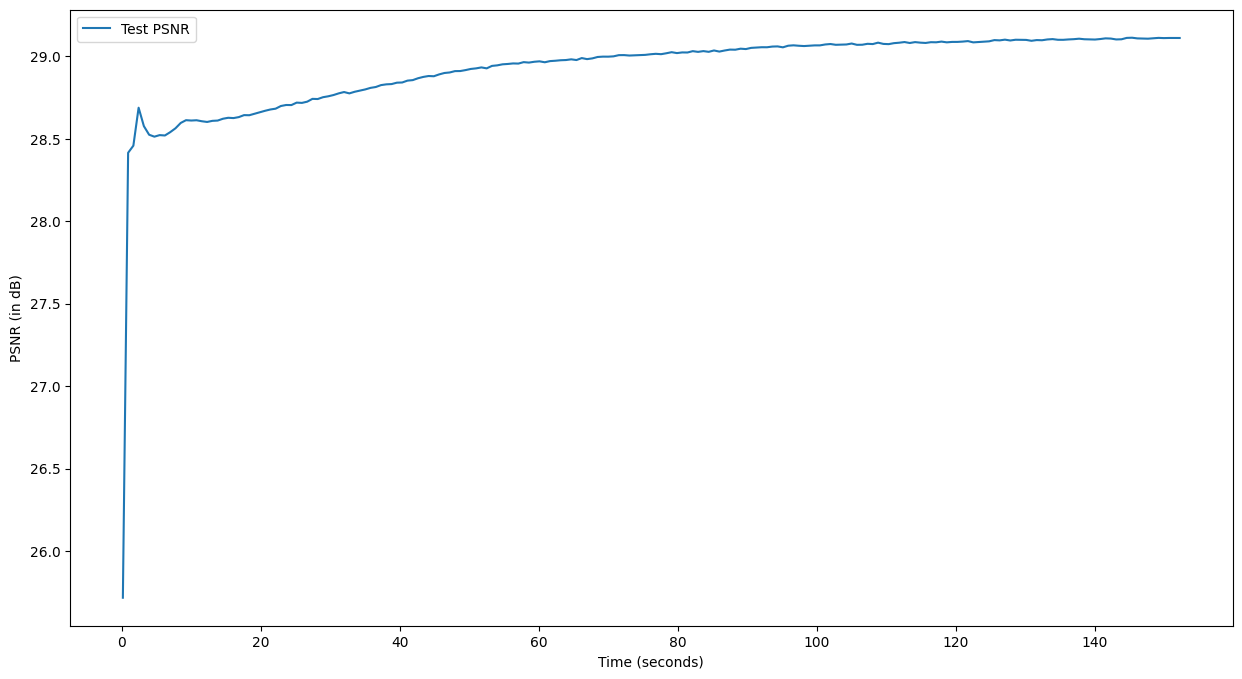

In [28]:

# Show PSNR wrt time
test_psnr_ys = np.array(training_metric_results["test_psnr"])
xs_time = np.array(training_metric_results["time"])
fig, axes = create_line_graph(xs_time, test_psnr_ys, ["Test PSNR"])




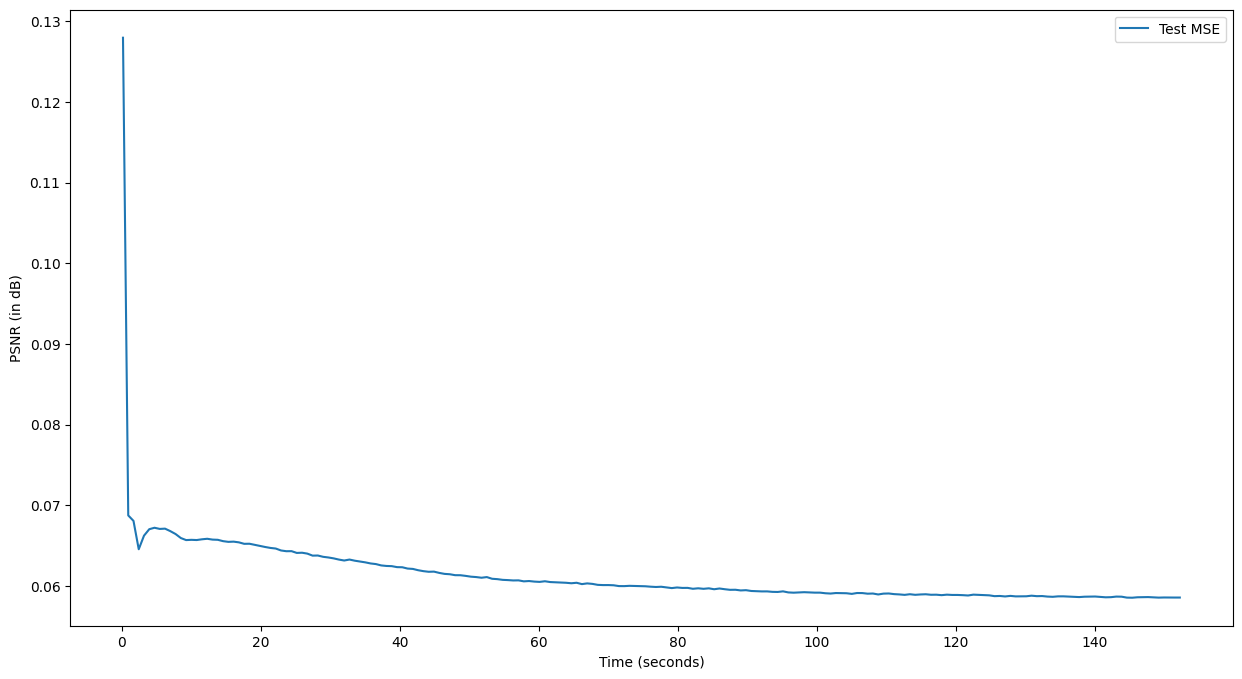

In [29]:
# Show test mse wrt time
test_mse_ys = np.array(training_metric_results["test_mse"])
fig, axes = create_line_graph(xs_time, test_mse_ys, ["Test MSE"])
